# Gini on instance level

Debunking the myth that the metric cannot be decomposed into individual components.

Author: https://www.github.com/deburky

In [36]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fastwoe.metrics import somersd_yx
from matplotlib.ticker import FuncFormatter

## Step 1: define the function

In [2]:
# Instance-level Gini contribution calculation
def gini_instance_contributions(
    scores: np.ndarray, labels: np.ndarray
) -> tuple[np.ndarray, float]:
    """
    Calculate each observation's contribution to Gini coefficient.

    This assigns credit/blame to each observation based on how well
    it's ranked relative to observations of the opposite class.

    For a positive (label=1):
      - Gets +1 for each negative it scores higher than (concordant)
      - Gets -1 for each negative it scores lower than (discordant)

    For a negative (label=0):
      - Gets +1 for each positive it scores lower than (concordant)
      - Gets -1 for each positive it scores higher than (discordant)

    Args:
        scores: Model scores.
        labels: Binary labels (0/1).

    Returns:
        contributions: Array of contribution for each observation.
        total_gini: Overall Gini coefficient.
    """
    n: int = len(scores)
    labels = labels.astype(int)

    # Total number of positive-negative pairs
    n_pos: int = int(np.sum(labels))
    n_neg: int = n - n_pos
    n_pairs: int = n_pos * n_neg

    if n_pairs == 0:
        return np.zeros(n), 0.0

    contributions = np.zeros(n)

    # For each observation, count its pairwise comparisons
    for i in range(n):
        score_i = scores[i]
        label_i = labels[i]

        # Compare to all observations with OPPOSITE label
        opposite_mask = labels != label_i
        opposite_scores = scores[opposite_mask]

        if label_i == 1:  # Positive observation
            # Concordant: positive scores higher than negative
            concordant = np.sum(score_i > opposite_scores)
            discordant = np.sum(score_i < opposite_scores)
        else:  # Negative observation
            # Concordant: negative scores lower than positive
            concordant = np.sum(score_i < opposite_scores)
            discordant = np.sum(score_i > opposite_scores)
        # Net contribution: ties get 0 credit (Somers' D / Gini, not AUC)
        contributions[i] = (concordant - discordant) / n_pairs

    # Total Gini is sum of contributions divided by 2
    # (each pair is counted once from the positive and once from the negative)
    total_gini: float = float(np.sum(contributions) / 2)

    return contributions, total_gini

## Step 2: Simulate data and calculate contributions

In [81]:
np.random.seed(42)

# Create example with some misranked observations
n = 20
labels = np.array(
    [
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,  # 10 negatives
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,  # 10 positives
    ]
)

# Generate scores with SOME overlap (imperfect model)
np.random.seed(42)
scores_good = np.concatenate(
    [
        np.array([0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]),  # negatives
        np.array([0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85]),  # positives
    ]
)

# This creates overlap: some positives score lower than some negatives
# Calculate contributions
contributions, gini_from_contrib = gini_instance_contributions(scores_good, labels)

# Calculate Gini using standard method
gini_standard = somersd_yx(labels, scores_good).statistic

print(
    f"\nDataset: {n} observations ({int(labels.sum())} positives, "
    f"{int((1 - labels).sum())} negatives)"
)
print(f"\nGini from contributions: {gini_from_contrib:.4f}")
print(f"Gini (Somers' D): {gini_standard:.4f}")
print(f"Difference: {abs(gini_from_contrib - gini_standard):.6f}")

# Show detailed contributions
df = pd.DataFrame(
    {
        "obs": range(n),
        "label": labels,
        "score": scores_good,
        "contribution": contributions,
    }
)

df = df.sort_values("contribution", ascending=False)

print("Top 5 positive contributors (help Gini)")
display(df.head(5))

print("Top 5 negative contributors (hurt Gini)")
display(df.tail(5))



Dataset: 20 observations (10 positives, 10 negatives)

Gini from contributions: 0.6400
Gini (Somers' D): 0.6400
Difference: 0.000000
Top 5 positive contributors (help Gini)


,obs,label,score,contribution
0,0,0,0.20,0.1
1,1,0,0.25,0.1
18,18,1,0.80,0.1
17,17,1,0.75,0.1
16,16,1,0.70,0.1


Top 5 negative contributors (hurt Gini)


,obs,label,score,contribution
12,12,1,0.50,0.03
8,8,0,0.60,0.01
11,11,1,0.45,0.01
9,9,0,0.65,-0.01
10,10,1,0.40,-0.01


In [ ]:
df.reset_index(drop=True).query("label == 0")["contribution"].sum()

0.64

## Step 3: Perform validation

In [9]:
scenarios = [
    (
        "Perfect discrimination",
        np.concatenate([np.full(10, 0.2), np.full(10, 0.8)]),
        labels,
    ),
    ("Random (no discrimination)", np.random.uniform(0, 1, 20), labels),
    (
        "Reverse (negative discrimination)",
        np.concatenate([np.full(10, 0.8), np.full(10, 0.2)]),
        labels,
    ),
]

for scenario_name, scenario_scores, scenario_labels in scenarios:
    contrib, gini_contrib = gini_instance_contributions(
        scenario_scores, scenario_labels
    )
    gini_standard = somersd_yx(scenario_labels, scenario_scores).statistic

    print(f"\n{scenario_name}:")
    print(f"Gini (contributions): {gini_contrib:.4f}")
    print(f"Gini (standard): {gini_standard:.4f}")
    print(f"Match: {'✓' if abs(gini_contrib - gini_standard) < 0.001 else '✗'}")

print("✓ Instance-level contributions correctly reconstruct Gini!")


Perfect discrimination:
Gini (contributions): 1.0000
Gini (standard): 1.0000
Match: ✓

Random (no discrimination):
Gini (contributions): 0.3200
Gini (standard): 0.3200
Match: ✓

Reverse (negative discrimination):
Gini (contributions): -1.0000
Gini (standard): -1.0000
Match: ✓
✓ Instance-level contributions correctly reconstruct Gini!


## Step 5: Visualize contributions

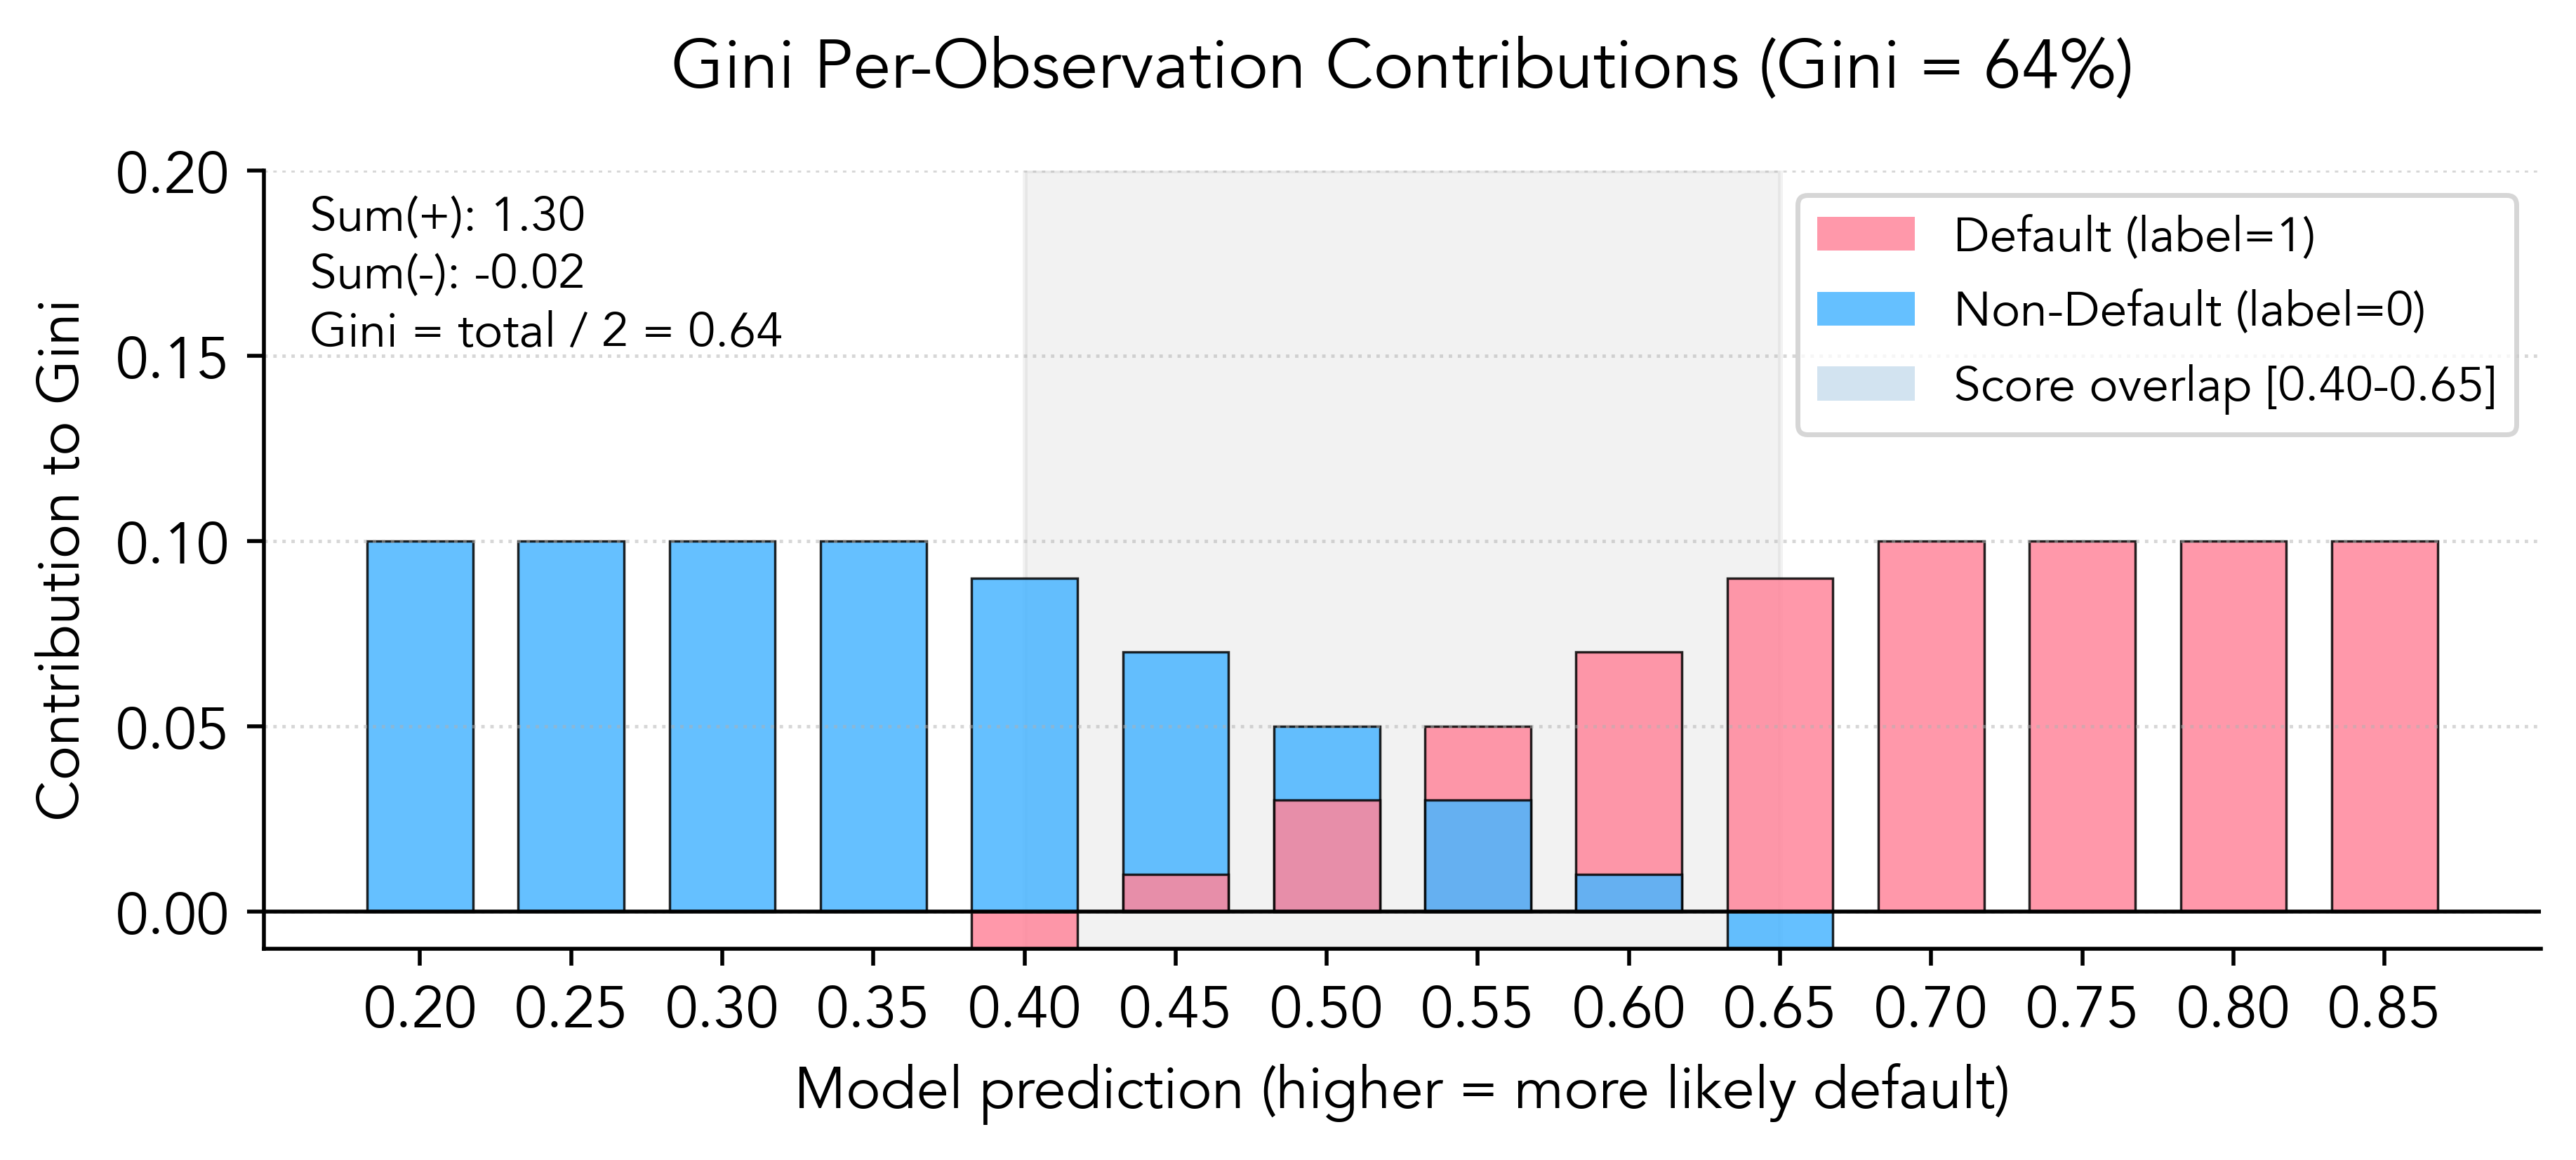

In [90]:
plt.rcParams["font.family"] = "Avenir"
plt.rcParams["font.size"] = 12

COLOR_POS = "#FF869B"
COLOR_NEG = "#4AB5FF"

df_plot = df.sort_values("score").reset_index(drop=True)

# Score range where both classes coexist
overlap_lo: float = float(
    max(
        df_plot[df_plot["label"] == 1]["score"].min(),
        df_plot[df_plot["label"] == 0]["score"].min(),
    )
)
overlap_hi: float = float(
    min(
        df_plot[df_plot["label"] == 1]["score"].max(),
        df_plot[df_plot["label"] == 0]["score"].max(),
    )
)

fig, ax = plt.subplots(figsize=(7.5, 3.5), dpi=500)

# Shade the overlap region — this is where negative contributors live
ax.axvspan(overlap_lo, overlap_hi, alpha=0.1, color="gray")

# Contribution bars, colored by class
bar_colors = [COLOR_POS if lbl == 1 else COLOR_NEG for lbl in df_plot["label"]]
ax.bar(
    df_plot["score"],
    df_plot["contribution"],
    width=0.035,
    color=bar_colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5,
)

# Zero and Gini reference lines
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(
    gini_from_contrib,
    color="gray",
    linewidth=1.0,
    linestyle="--",
    alpha=0.5,
)

# Summary: positive / negative breakdown → Gini
pos_sum: float = float(df_plot[df_plot["contribution"] > 0]["contribution"].sum())
neg_sum: float = float(df_plot[df_plot["contribution"] < 0]["contribution"].sum())
summary = f"Sum(+): {pos_sum:.2f}\nSum(-): {neg_sum:.2f}\nGini = total / 2 = {gini_from_contrib:.2f}"
ax.text(
    0.02,
    0.97,
    summary,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
)

legend_elements = [
    mpatches.Patch(facecolor=COLOR_POS, alpha=0.85, label="Default (label=1)"),
    mpatches.Patch(facecolor=COLOR_NEG, alpha=0.85, label="Non-Default (label=0)"),
    mpatches.Patch(
        # facecolor="gray",
        alpha=0.2,
        label=f"Score overlap [{overlap_lo:.2f}-{overlap_hi:.2f}]",
    ),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)
# Set x-axis ticks to show ALL unique scores
ax.set_xticks(df_plot["score"].unique())

# Format x-axis as percentages manually
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.2f}"))

# Rotate labels if needed for readability
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha="center")

ax.set_xlabel("Model prediction (higher = more likely default)")
ax.set_ylabel("Contribution to Gini")
ax.set_title(
    f"Gini Per-Observation Contributions (Gini = {gini_from_contrib:.0%})",
    fontsize=14,
    y=1.07,
    fontweight="bold",
)
# remove upper and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="dotted", linewidth=0.7, alpha=0.5, axis="y")
ax.set_ylim(-0.01, 0.2)
plt.tight_layout()
plt.savefig("gini_contributions.png", dpi=500, bbox_inches="tight")
plt.show()
# plt.close()
# print("Saved: gini_contributions.png")